# Laboratorio 6: Git Wars - SVMs

**Duración:** 2 horas  
**Formato:** Competencia por Pull Requests  
**Repositorio base:** https://github.com/JAlbertoAlonso/gitwars-svm 

---

## Portada del equipo

**Integrantes:**
- Imanol Mendoza Saenz de Buruaga
- Erick José Fabián Sandoval
- Alejandro Iram Ramírez Nava
- Erick Yair Aguilar Martinez

**Repositorio del equipo:**  
<https://github.com/Eickyair/gitwars-svm>

**Fecha de entrega:**  
18/10/2025

## Fase 1 - Implementación de hinge loss

### Código - Fase 1

In [1]:
import numpy as np

# TODO: Implementar la pérdida hinge y su gradiente
def hinge_loss(w, b, X, y, C):
    '''
    Calcula la pérdida hinge regularizada del SVM lineal.
    L(w,b) = 0.5 * ||w||^2 + C * sum_i max(0, 1 - y_i * (w^T x_i + b))
    
    Parámetros
    ----------
    w : array-like de forma (n_features,) o (n_features, 1)
    b : escalar (float)
    X : array-like de forma (n_samples, n_features) o (n_features,)
    y : array-like de forma (n_samples,) con etiquetas en {-1, 1} o {0, 1}
    C : escalar (float)

    Retorna
    -------
    L : float
        Valor escalar de la pérdida.
    '''
    # Conversión de tipos y formas (robustez a listas, 1D, etc.)
    X = np.asarray(X, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    b = float(b)
    C = float(C)

    # Asegurar que X sea 2D y compatible
    if X.ndim == 1:
        # Caso borde: un único ejemplo
        X = X.reshape(1, -1)
    n_samples, n_features = X.shape

    if w.shape[0] != n_features:
        raise ValueError(f"w tiene {w.shape[0]} features, pero X tiene {n_features} columnas.")

    if y.shape[0] != n_samples:
        raise ValueError(f"y tiene {y.shape[0]} muestras, pero X tiene {n_samples} filas.")

    # Normalizar etiquetas: permitir {0,1} -> {-1,1}
    y_unique = np.unique(y)
    if set(y_unique).issubset({0.0, 1.0}):
        y = np.where(y == 0.0, -1.0, 1.0)
    elif not set(y_unique).issubset({-1.0, 1.0}):
        raise ValueError("y debe contener solo etiquetas en {-1, 1} o {0, 1}.")

    # Márgenes y pérdidas hinge (vectorizado y estable)
    margins = y * (X.dot(w) + b)                 # shape: (n_samples,)
    losses = np.maximum(0.0, 1.0 - margins)      # hinge por muestra

    # Regularización + suma de pérdidas (usar float64 para estabilidad en lotes grandes)
    reg = 0.5 * np.dot(w, w)
    data_term = C * np.sum(losses, dtype=np.float64)

    return float(reg + data_term)


import pandas as pd
df=pd.read_csv('./data/train_linear.csv')
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values
w = np.array([0.5, -0.2])
b = 0.1 
C = 1.0
loss = hinge_loss(w, b, X, y, C)
print("Hinge Loss:", loss)

Hinge Loss: 45.5445795900531


### Análisis - Fase 1

1. ¿Qué penaliza el término $0.5\|w\|^2$ y qué controla $C$?

Penaliza la complejidad del modelo. La C penaliza los errores de manera que si C es pequeño el margen es mas olgado y si C es grande le da mas importancia a los errores por lo que el margen se reduce.
1. ¿Cuándo la parte *hinge* contribuye con 0 al costo?

Cuando el punto esta fuera del margen unitario y clasificado correctamente

### Bitácora de control de versiones — Fase 1

```bash
git branch fase1_bubble_sort #crea la rama fase1_bubble_sort
# combina los cambios de la rama main
# que estan en el repo https://github.com/JAlbertoAlonso/gitwars-svm/
git pull upstream main
git status #muestra las modificaciones con respecto al anterior commit de manera local
git add fase1_bubble_sort.py #agrega al stage
git commit -m "feat(fase1): perdida hinge"
git push origin fase1_bubble_sort #crea en el repositorio
# remoto la rama fase1_bubble_sort y lo actualiza con
# nuestro cambios locales(commit)
```

## Fase 2 - Entrenamiento lineal

### Código - Fase 2

Fuente de datos: train_linear.csv
n=200, d=2
L final: 0.722061
Accuracy final: 0.9750
w = [ 1.12033732 -0.16850964], b = 0.116000


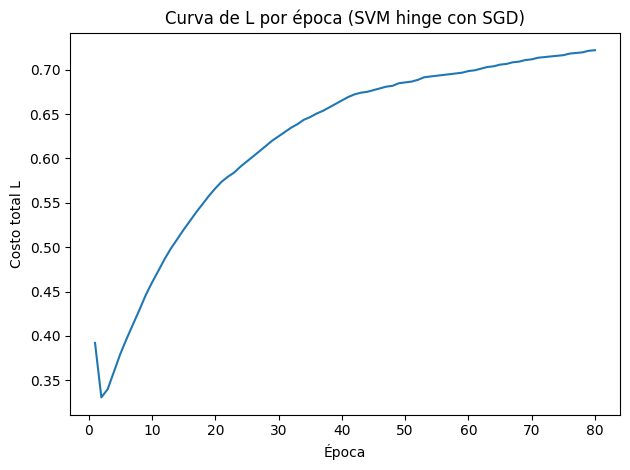

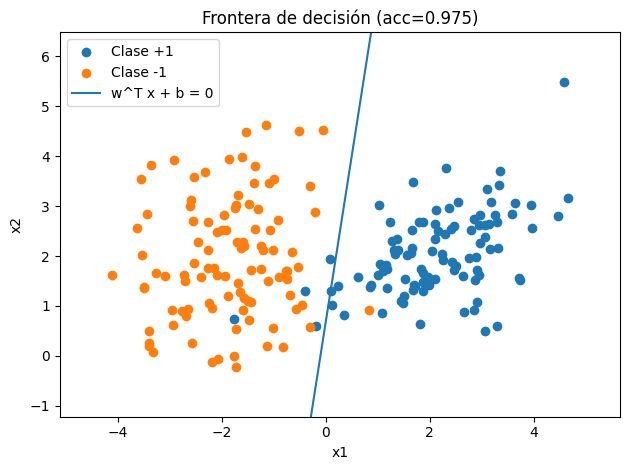

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


rng = np.random.RandomState(4)
if os.path.exists("./data/train_linear.csv"):
    df = pd.read_csv("./data/train_linear.csv")
    cols = [c.lower() for c in df.columns]
    df.columns = cols
    # intenta x1, x2, y; si no, toma dos primeras numéricas como X y la última numérica como y
    if {'x1','x2','y'}.issubset(set(cols)):
        X = df[['x1','x2']].to_numpy(dtype=float)
        y = df['y'].to_numpy(dtype=float)
    else:
        num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
        if len(num_cols) < 3:
            raise ValueError("El CSV debe tener ≥2 columnas numéricas de features y 1 de etiqueta.")
        X = df[num_cols[:2]].to_numpy(dtype=float)
        y = df[num_cols[-1]].to_numpy(dtype=float)
    # mapear etiquetas a {-1, +1}
    yu = np.unique(y)
    if set(yu).issubset({0.0, 1.0}):
        y = np.where(y == 0.0, -1.0, 1.0)
    elif not set(yu).issubset({-1.0, 1.0}):
        # si hay dos valores, mapéalos a {-1,+1}
        if len(yu) == 2:
            y = np.where(y == yu[0], -1.0, 1.0)
        else:
            raise ValueError("La etiqueta y debe tener solo 2 clases.")
    fuente = "train_linear.csv"
else:
    # Fallback sintético 
    n = 200
    X_pos = rng.randn(n//2, 2) + np.array([2.0, 2.0])
    X_neg = rng.randn(n//2, 2) + np.array([-2.0, -2.0])
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(n//2), -np.ones(n//2)])
    fuente = "synthetic_fallback (sube train_linear.csv para usar tus datos)"


# Hiperparámetros
C = 1.0
eta = 0.001          # tasa de aprendizaje
epochs = 80
batch_size = 32
seed = 42


n, d = X.shape
w = np.zeros(d, dtype=float)
b = 0.0
hist_L = []


rng = np.random.RandomState(seed)
for epoch in range(1, epochs + 1):
    # shuffle data
    idx = rng.permutation(n)
    Xs, ys = X[idx], y[idx]

    # minibatches
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        Xb = Xs[start:end]
        yb = ys[start:end]

        # margin_i = y_i * (w·x_i + b)
        margins = yb * (Xb @ w + b)

        # if margin >= 1 => grad_w = w ; grad_b = 0
        # else           => grad_w = w - C * y_i * x_i ; grad_b = - C * y_i
        mask_bad = margins < 1.0

        grad_w = w.copy()
        if np.any(mask_bad):
            grad_w = grad_w - C * (Xb[mask_bad].T @ yb[mask_bad])

        grad_b = 0.0
        if np.any(mask_bad):
            grad_b = - C * np.sum(yb[mask_bad])

        # updates
        w = w - eta * grad_w
        b = b - eta * grad_b

   
    margins_all = y * (X @ w + b)
    hinge = np.maximum(0.0, 1.0 - margins_all)
    hinge_loss = np.mean(hinge)
    L = 0.5 * np.dot(w, w) + C * hinge_loss
    hist_L.append(L)

# -------------------------
# Métrica (accuracy final)
pred = np.sign(X @ w + b)
pred[pred == 0] = 1.0
acc = np.mean(pred == y)

print(f"Fuente de datos: {fuente}")
print(f"n={n}, d={d}")
print(f"L final: {hist_L[-1]:.6f}")
print(f"Accuracy final: {acc:.4f}")
print(f"w = {w}, b = {b:.6f}")

# -------------------------
# Gráfica de L por época
plt.figure()
plt.plot(np.arange(1, len(hist_L)+1), hist_L)
plt.xlabel("Época")
plt.ylabel("Costo total L")
plt.title("Curva de L por época (SVM hinge con SGD)")
plt.tight_layout()
plt.show()

# -------------------------
# Frontera de decisión (2D)
if d == 2 and abs(w[1]) > 1e-12:
    xmin, xmax = X[:,0].min()-1, X[:,0].max()+1
    ymin, ymax = X[:,1].min()-1, X[:,1].max()+1
    xx = np.linspace(xmin, xmax, 200)
    yy = -(w[0]/w[1]) * xx - b / w[1]
    plt.figure()
    plt.scatter(X[y==1,0], X[y==1,1], label="Clase +1")
    plt.scatter(X[y==-1,0], X[y==-1,1], label="Clase -1")
    plt.plot(xx, yy, label="w^T x + b = 0")
    plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title(f"Frontera de decisión (acc={acc:.3f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Análisis - Fase 2

1. ¿Cómo afecta $C$ la cantidad de violaciones al margen?

Hinge loss es un contabilizador de los errores o violaciones al margen. Así que en el término C*hinge_loss, C escala la cantidad de errores

2. ¿Qué ocurre si la tasa de aprendizaje es muy grande o muy pequeña?

Si la tasa es muy pequeña, puede tardar mucho en converger al mínimo, si en cambio es muy grande, puede oscilar alrededor del mínimo (lo cual es costoso en tiempo) o diverger. 

### Bitácora de control de versiones — Fase 2

```bash
git branch fase2_bubble_sort
git pull upstream # combina los cambios a fase2_bubble_sort
git status #muestra las modificaciones con respecto al anterior commit de manera local
git add fase2_bubble_sort.py #agrega al stage
git commit -m "feat(fase2_bubble_sort): programamos descenso de gradiente con la perdida hinge"
git push origin fase2_bubble_sort # subimos a fork para luego hacer un pr
```

## Fase 3 - Visualización y análisis del margen

### Código - Fase 3

Fuente de datos: train_linear.csv
n=200, d=2
L final: 0.756058
Accuracy final: 0.9750
w = [ 1.13555897 -0.25975184], b = 0.275000


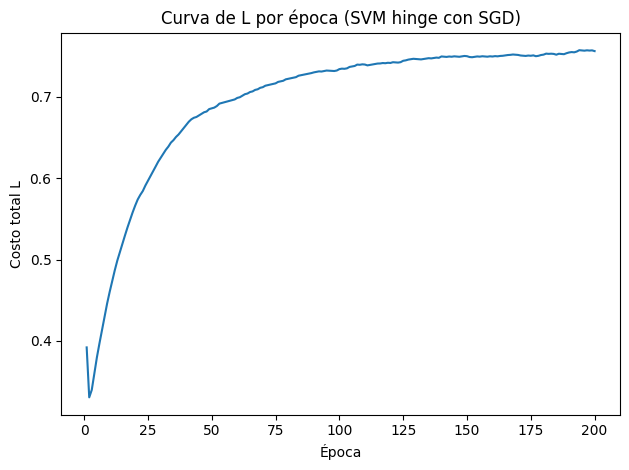

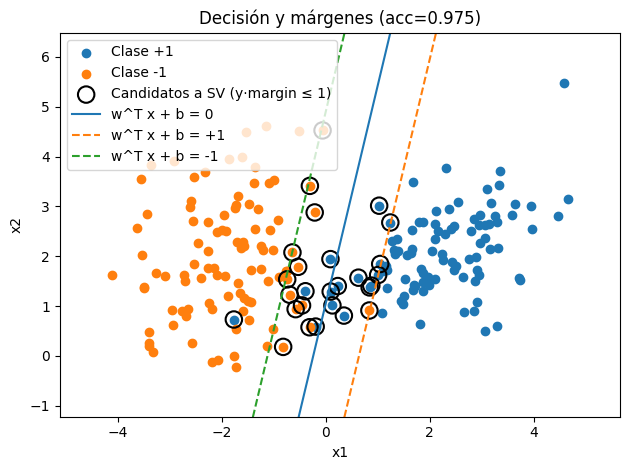

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Carga de datos (simple)
# -------------------------
rng = np.random.RandomState(4)
if os.path.exists("./data/train_linear.csv"):
    df = pd.read_csv("./data/train_linear.csv")
    cols = [c.lower() for c in df.columns]
    df.columns = cols
    if {'x1','x2','y'}.issubset(set(cols)):
        X = df[['x1','x2']].to_numpy(dtype=float)
        y = df['y'].to_numpy(dtype=float)
    else:
        num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
        if len(num_cols) < 3:
            raise ValueError("El CSV debe tener ≥2 columnas numéricas de features y 1 de etiqueta.")
        X = df[num_cols[:2]].to_numpy(dtype=float)
        y = df[num_cols[-1]].to_numpy(dtype=float)
    yu = np.unique(y)
    if set(yu).issubset({0.0, 1.0}):
        y = np.where(y == 0.0, -1.0, 1.0)
    elif not set(yu).issubset({-1.0, 1.0}):
        if len(yu) == 2:
            y = np.where(y == yu[0], -1.0, 1.0)
        else:
            raise ValueError("La etiqueta y debe tener solo 2 clases.")
    fuente = "train_linear.csv"
else:
    n = 200
    X_pos = rng.randn(n//2, 2) + np.array([2.0, 2.0])
    X_neg = rng.randn(n//2, 2) + np.array([-2.0, -2.0])
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(n//2), -np.ones(n//2)])
    fuente = "synthetic_fallback"

# -------------------------
# Hiperparámetros
# -------------------------
C = 1
eta = 0.001
epochs = 200
batch_size = 32
seed = 42

# -------------------------
# Init
# -------------------------
n, d = X.shape
w = np.zeros(d, dtype=float)
b = 0.0
hist_L = []

# -------------------------
# Entrenamiento
# -------------------------
rng = np.random.RandomState(seed)
for epoch in range(1, epochs + 1):
    idx = rng.permutation(n)
    Xs, ys = X[idx], y[idx]

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        Xb = Xs[start:end]
        yb = ys[start:end]

        margins = yb * (Xb @ w + b)
        mask_bad = margins < 1.0

        grad_w = w.copy()
        if np.any(mask_bad):
            grad_w = grad_w - C * (Xb[mask_bad].T @ yb[mask_bad])
        grad_b = 0.0
        if np.any(mask_bad):
            grad_b = - C * np.sum(yb[mask_bad])

        w = w - eta * grad_w
        b = b - eta * grad_b

    # costo total L por época
    margins_all = y * (X @ w + b)
    hinge = np.maximum(0.0, 1.0 - margins_all)
    hinge_loss = np.mean(hinge)
    L = 0.5 * np.dot(w, w) + C * hinge_loss
    hist_L.append(L)

# -------------------------
# Métrica (accuracy final)
# -------------------------
pred = np.sign(X @ w + b)
pred[pred == 0] = 1.0
acc = np.mean(pred == y)

print(f"Fuente de datos: {fuente}")
print(f"n={n}, d={d}")
print(f"L final: {hist_L[-1]:.6f}")
print(f"Accuracy final: {acc:.4f}")
print(f"w = {w}, b = {b:.6f}")

# -------------------------
# Curva de L por época
# -------------------------
plt.figure()
plt.plot(np.arange(1, len(hist_L)+1), hist_L)
plt.xlabel("Época")
plt.ylabel("Costo total L")
plt.title("Curva de L por época (SVM hinge con SGD)")
plt.tight_layout()
plt.show()

# -------------------------
# Gráfico: datos, recta w^T x + b = 0, márgenes ±1,
# y resaltado de candidatos a SV (y_i(w^T x_i + b) <= 1)
# -------------------------
if d == 2:
    xmin, xmax = X[:,0].min()-1, X[:,0].max()+1
    ymin, ymax = X[:,1].min()-1, X[:,1].max()+1

    # Máscara de candidatos a SV
    margins_all = y * (X @ w + b)
    sv_mask = margins_all <= 1.0 + 1e-12

    plt.figure()
    # Datos base
    plt.scatter(X[y==1,0],  X[y==1,1],  label="Clase +1")
    plt.scatter(X[y==-1,0], X[y==-1,1], label="Clase -1")

    # Resaltar SV (círculos huecos grandes)
    plt.scatter(X[sv_mask,0], X[sv_mask,1],
                s=140, facecolors='none', edgecolors='k', linewidths=1.5,
                label="Candidatos a SV (y·margin ≤ 1)")

    # Líneas: decisión y márgenes
    if abs(w[1]) > 1e-12:
        xx = np.linspace(xmin, xmax, 400)
        # w0*x + w1*y + b = c  => y = -(w0/w1)x - (b-c)/w1
        yy0  = -(w[0]/w[1])*xx -  b/ w[1]        # c = 0
        yy_p = -(w[0]/w[1])*xx - (b-1)/w[1]      # c = +1
        yy_m = -(w[0]/w[1])*xx - (b+1)/w[1]      # c = -1
        plt.plot(xx, yy0,  label="w^T x + b = 0")
        plt.plot(xx, yy_p, linestyle="--", label="w^T x + b = +1")
        plt.plot(xx, yy_m, linestyle="--", label="w^T x + b = -1")
    else:
        # Rectas verticales: x = const
        # w0*x + b = c  => x = (c - b)/w0
        x0  = (0.0 - b) / w[0]
        xp1 = (1.0 - b) / w[0]
        xm1 = (-1.0 - b) / w[0]
        plt.axvline(x0,  label="w^T x + b = 0")
        plt.axvline(xp1, linestyle="--", label="w^T x + b = +1")
        plt.axvline(xm1, linestyle="--", label="w^T x + b = -1")

    plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title(f"Decisión y márgenes (acc={acc:.3f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Análisis - Fase 3


1. ¿Qué relación hay entre el ancho del margen y \|w\|?  

El margen se define como el producto interior entre nuestro dato x y w, si los coeficientes de w son grandes en magnitud entonces este producto interior aumentara, es decir, el margen aumenta conforme la norma de w lo hace.

2. ¿Por qué modificar $b$ desplaza la frontera sin cambiar su orientación?

Porque la b,que es el bias, solo traslada la recta pero no modifica su orientación, esto es debido a que simplemente esta sumando un escalar dando origen a una traslación.

### Bitácora de control de versiones — Fase 3

```bash
git branch fase3_bubble_sort
git pull upstream # combina los cambios a fase2_bubble_sort
git status #muestra las modificaciones con respecto al anterior commit de manera local
git add fase3_bubble_sort.py #agrega al stage
git commit -m "feat(fase3_bubble_sort): Mostramos margenes del svm lineal"
git push origin fase3_bubble_sort # subimos a fork para luego hacer un pr
```

## Fase 4 - Idea dual + Kernel RBF

### Código - Fase 4

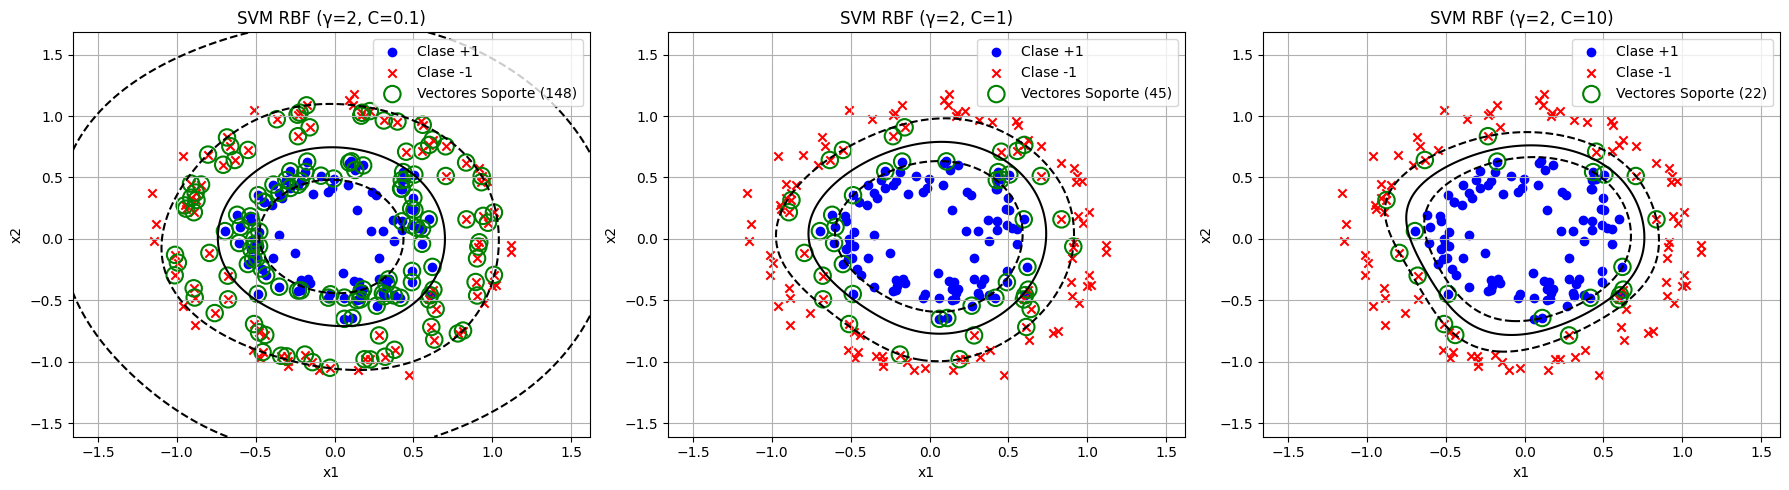

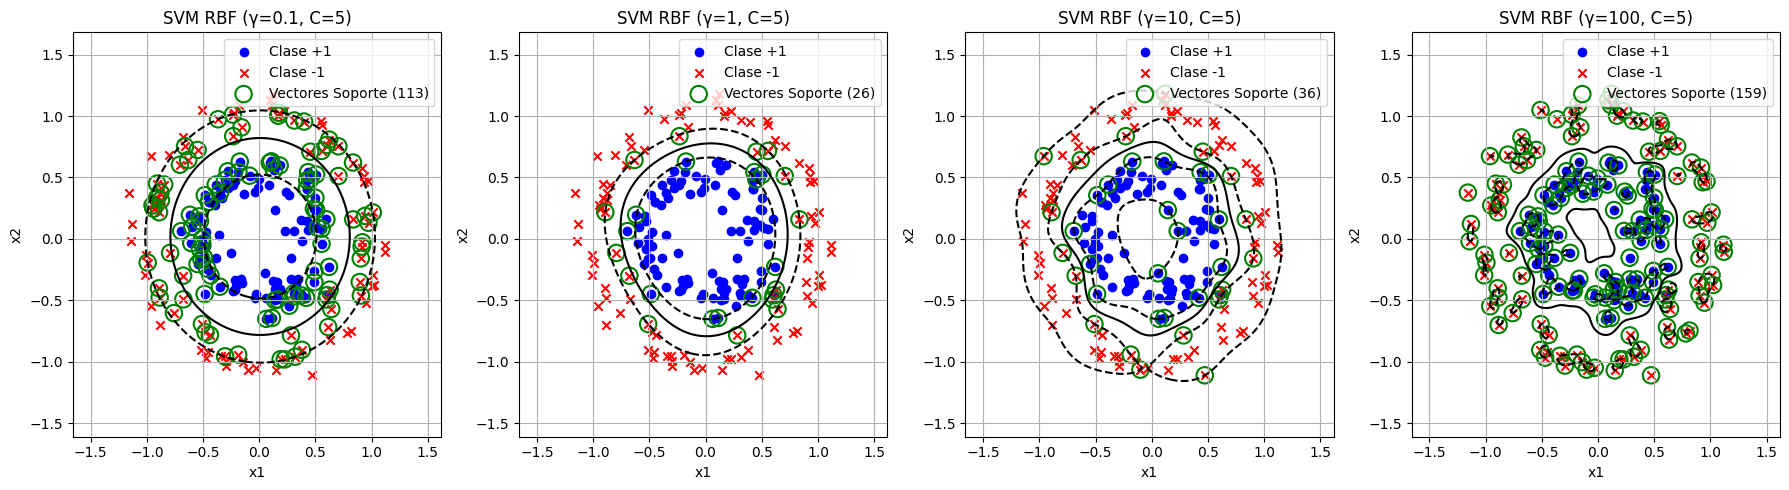

In [4]:
# CÓDIGO IMPLEMENTADO POR DINOSAURIOS
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import pandas as pd

def rbf_kernel(X1, X2, gamma):
    """
    Implementa el kernel RBF: K(x,z) = exp(-gamma ||x-z||^2)
    """
    dist_matrix = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * dist_matrix)

def plot_svm_rbf_decision_boundary(X, y, svm_model, gamma, C, title=None):
    """
    Visualiza la frontera de decisión del SVM con kernel RBF
    """
    plt.figure(figsize=(12, 8))
    
    # Crear malla para visualización
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                        np.linspace(y_min, y_max, 200))
    
    # Evaluar el modelo en la malla
    Z = svm_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Graficar contornos de decisión
    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1],
                linestyles=['--', '-', '--'])
    plt.plot([], [], 'k-', label='Frontera de decisión')
    plt.plot([], [], 'k--', label='Márgenes')
    
    # Graficar puntos de datos
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='b', marker='o',
               label='Clase +1')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], c='r', marker='x',
               label='Clase -1')
    
    # Resaltar vectores soporte
    support_vectors = svm_model.support_vectors_
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
               s=200, facecolors='none', edgecolors='g',
               label='Vectores Soporte')

    # Configuración del gráfico
    if title is None:
        title = f'SVM con Kernel RBF (γ={gamma}, C={C})\n'
        title += f'Vectores Soporte: {len(support_vectors)}'
    plt.title(title)
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.legend()
    plt.grid(True)




df = pd.read_csv("./data/train_nonlinear.csv")
X = df[['x1','x2']].to_numpy()
y = df['y'].to_numpy()


# Entrenar y visualizar en subplots 1x3
gamma_val = 2
C_vals = [0.1, 1, 10]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Malla compartida
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, C_val in zip(axes, C_vals):
    svm_rbf = SVC(kernel='rbf', gamma=gamma_val, C=C_val)
    svm_rbf.fit(X, y)

    # Evaluar en la malla y dibujar contornos
    Z = svm_rbf.decision_function(grid).reshape(xx.shape)
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1],
               linestyles=['--', '-', '--'])

    # Puntos de datos
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='b', marker='o', label='Clase +1')
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c='r', marker='x', label='Clase -1')

    # Vectores soporte
    sv = svm_rbf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1],
               s=140, facecolors='none', edgecolors='g',
               linewidths=1.5, label=f'Vectores Soporte ({len(sv)})')

    ax.set_title(f'SVM RBF (γ={gamma_val}, C={C_val})')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# Entrenar y visualizar en subplots 1x3
C_val = 5
gamma_vals = [0.1, 1, 10,100]

fig, axes = plt.subplots(1, len(gamma_vals), figsize=(18, 5))

# Malla compartida
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, gamma_val in zip(axes, gamma_vals):
    svm_rbf = SVC(kernel='rbf', gamma=gamma_val, C=C_val)
    svm_rbf.fit(X, y)

    # Evaluar en la malla y dibujar contornos
    Z = svm_rbf.decision_function(grid).reshape(xx.shape)
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1],
               linestyles=['--', '-', '--'])

    # Puntos de datos
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='b', marker='o', label='Clase +1')
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c='r', marker='x', label='Clase -1')

    # Vectores soporte
    sv = svm_rbf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1],
               s=140, facecolors='none', edgecolors='g',
               linewidths=1.5, label=f'Vectores Soporte ({len(sv)})')

    ax.set_title(f'SVM RBF (γ={gamma_val}, C={C_val})')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


### Análisis - Fase 4

1. ¿Qué sucede al aumentar $γ$ en la suavidad de la frontera?

EL parametro γ se usa en los SVM´s con kernel RBF gaussiano y modela la influencia que tiene cada punto de manera que si es γ pequeño cada punto tiene influencia más amplia por lo que el modelo va a ser más suave y menos complejo, en cambio, si es γ grande cada punto solo va a afectar a su entorno local lo que implica que va a ajustar más al ruido y menos complejo (menor suavidad en la frontera).

2. ¿Cómo interactúan $C$ y $γ$ en el sobreajuste o subajuste?

Si C es muy grande propicia el sobreajuste, de igual manera, cuando γ es muy grande tambien propicia el sobreajuste.

### Bitácora de control de versiones — Fase 4

```bash
git branch fase4_bubble_sort
git pull upstream # combina los cambios a fase2_bubble_sort
git status #muestra las modificaciones con respecto al anterior commit de manera local
git add fase4_bubble_sort.py #agrega al stage
git commit -m "feat(fase4_bubble_sort): Mostramos margenes del svm-kernel rbf"
git push origin fase4_bubble_sort # subimos a fork para luego hacer un pr
```

## Conclusiones finales

En esta práctica y las anteriores, junto con la teoría revisada, se entiende mejor por qué durante muchos años los modelos **SVM** fueron considerados una referencia.
Esto se debe a que reúnen varios elementos teóricos que los hacen buenos:

- **Función de pérdida convexa.**  
  El SVM utiliza una pérdida tipo *hinge*, que es convexa. Esto significa que el proceso de entrenamiento no se pierde en mínimos locales y siempre converge a una única solución óptima. En la práctica, esto se traduce en un modelo y estable al entrenar.

- **Capacidad para manejar relaciones no lineales.**
  A través del uso de los **kernel tricks**(ya que solo necesitamos la información del producto interior), el SVM puede proyectar los datos a espacios de mayor dimensión donde las clases o relaciones se vuelven separables. Así, sin cambiar el modelo base, logra representar patrones mucho más complejos que un simple modelo lineal.

- **Regularización contra el sobreajuste.**  
  Su función objetivo incluye un término que controla la magnitud de los parámetros (la norma de $w$). Esto actúa como un “freno” que evita que el modelo se ajuste demasiado a los datos de entrenamiento, mejorando su capacidad de generalización.

- **Maximización del margen.**  
  Además, el SVM busca no solo clasificar correctamente, sino hacerlo con el **mayor margen posible** entre las clases. Ese margen funciona como una protección natural contra errores en los datos o ruido, lo que contribuye a su generalización.

